In [ ]:

# Create "months.csv"
import csv
import calendar
from datetime import datetime, date

# Load decision dates from Prediction_all.csv, keep latest per month
decision_by_month = {}
with open('Prediction_all.csv') as f:
    reader = csv.DictReader(f)
    for row in reader:
        d = datetime.strptime(row['decision_date'], '%Y-%m-%d').date()
        key = (d.year, d.month)
        if key not in decision_by_month or d > decision_by_month[key]:
            decision_by_month[key] = d

# Month range: Feb 2023 to Jun 2026
months = []
y, m = 2023, 2
while (y, m) <= (2026, 6):
    months.append((y, m))
    m += 1
    if m > 12:
        m = 1
        y += 1

rows = []
for (y, m) in months:
    month_label = date(y, m, 1).strftime('%Y-%m')
    total_days = calendar.monthrange(y, m)[1]
    if (y, m) in decision_by_month:
        dec_day = decision_by_month[(y, m)].day
        days_before_incl = dec_day
        days_after = total_days - dec_day
        fraction = days_before_incl / total_days
        rows.append([month_label, 'Y', days_before_incl, days_after, total_days, round(fraction, 6)])
    else:
        rows.append([month_label, 'N', '', '', '', ''])

with open('months.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['month', 'decision', 'days_up_to_incl', 'days_after', 'total_days', 'frac_up_to_incl'])
    writer.writerows(rows)

print("Written months.csv")
for r in rows:
    print(r)


In [ ]:

# Create "rate_from_future.csv"
import csv

# Load months.csv into a dict keyed by (year, month)
months_info = {}
with open('months.csv') as f:
    reader = csv.DictReader(f)
    for row in reader:
        y, m = map(int, row['month'].split('-'))
        months_info[(y, m)] = row  # keys: decision, days_up_to_incl, days_after, total_days, frac_up_to_incl

def parse_contrdate(cd):
    """ContrDate is MMYY (no leading zero): e.g. 225 -> (2025, 2), 1023 -> (2023, 10)"""
    cd = int(cd)
    month = cd // 100
    year = 2000 + (cd % 100)
    return year, month

def prev_month(y, m):
    return (y - 1, 12) if m == 1 else (y, m - 1)

def next_month(y, m):
    return (y + 1, 1) if m == 12 else (y, m + 1)

# First pass: load all rows and build lookup {(date_str, (year, month)): Monthly_Rate}
all_rows = []
rate_lookup = {}  # (date_str, (year, month)) -> Monthly_Rate float
with open('effr_futures.csv') as fin:
    reader = csv.DictReader(fin)
    original_fieldnames = reader.fieldnames
    for row in reader:
        ym = parse_contrdate(row['ContrDate'])
        info = months_info.get(ym, {})
        months_cols = ['decision', 'days_up_to_incl', 'days_after', 'total_days', 'frac_up_to_incl']
        for col in months_cols:
            row[col] = info.get(col, '')
        try:
            mr = round(100 - float(row['Settlement']), 6)
            row['Monthly_Rate'] = mr
        except (ValueError, TypeError):
            row['Monthly_Rate'] = ''
            mr = None
        row['_ym'] = ym  # temp field
        all_rows.append(row)
        if mr is not None:
            rate_lookup[(row['Date_'], ym)] = mr

# Second pass: compute Hike_from_prev, Hike_to_next, and Hike
months_cols = ['decision', 'days_up_to_incl', 'days_after', 'total_days', 'frac_up_to_incl']
fieldnames = original_fieldnames + months_cols + ['Monthly_Rate', 'Hike_from_prev', 'Hike_to_next', 'Hike']

with open('rate_from_future.csv', 'w', newline='') as fout:
    writer = csv.DictWriter(fout, fieldnames=fieldnames, extrasaction='ignore')
    writer.writeheader()
    for row in all_rows:
        ym = row['_ym']
        hike_from_prev = ''
        hike_to_next = ''
        if row['decision'] == 'Y':
            try:
                frac = float(row['frac_up_to_incl'])
                curr_rate = float(row['Monthly_Rate'])
                date_ = row['Date_']

                pym = prev_month(*ym)
                if months_info.get(pym, {}).get('decision') == 'N':
                    prev_rate = rate_lookup.get((date_, pym))
                    if prev_rate is not None and (1 - frac) != 0:
                        hike_from_prev = round((curr_rate - prev_rate) / (1 - frac), 6)

                nym = next_month(*ym)
                if months_info.get(nym, {}).get('decision') == 'N':
                    next_rate = rate_lookup.get((date_, nym))
                    if next_rate is not None and frac != 0:
                        hike_to_next = round((next_rate - curr_rate) / frac, 6)
            except (ValueError, TypeError):
                pass

        row['Hike_from_prev'] = hike_from_prev
        row['Hike_to_next'] = hike_to_next

        if hike_from_prev != '' and hike_to_next != '':
            row['Hike'] = round((hike_from_prev + hike_to_next) / 2, 6)
        elif hike_from_prev != '':
            row['Hike'] = hike_from_prev
        elif hike_to_next != '':
            row['Hike'] = hike_to_next
        else:
            row['Hike'] = ''

        writer.writerow(row)

print("Written rate_from_future.csv")


* Some months have 2 consecutive days

* Some decisions occur last day of month

* Is impact day after???

In [ ]:

# Create "expectations.csv"
import csv
from datetime import datetime

# Outcome values in % (not basis points, consistent with futures)
KALSHI_OUTCOMES = {
    'kalshi_C25':  -0.25,
    'kalshi_C50+': -0.75,
    'kalshi_H0':    0.00,
    'kalshi_H25':  +0.25,
    'kalshi_H50':  +0.50,
    'kalshi_H50+': +0.75,
}
POLY_OUTCOMES = {
    'polymarket_C25':   -0.25,
    'polymarket_C50':   -0.50,
    'polymarket_C50+':  -0.75,
    'polymarket_C75+':  -0.75,
    'polymarket_H0':     0.00,
    'polymarket_H25':   +0.25,
    'polymarket_H25+':  +0.25,
    'polymarket_H50':   +0.50,
    'polymarket_H50+':  +0.75,
    'polymarket_H75':   +0.75,
}

def weighted_avg(row, outcome_map):
    vals = {col: float(row[col]) for col in outcome_map if row.get(col)}
    if not vals:
        return ''
    total = sum(vals.values())
    if total == 0:
        return ''
    return round(sum(p * outcome_map[col] for col, p in vals.items()) / total, 6)

# Build futures Hike lookup: (observed_date, contract_year, contract_month) -> Hike
def parse_contrdate(cd):
    cd = int(cd)
    return 2000 + (cd % 100), cd // 100

futures_lookup = {}  # (date_str, year, month) -> Hike
with open('rate_from_future.csv') as f:
    for row in csv.DictReader(f):
        y, m = parse_contrdate(row['ContrDate'])
        key = (row['Date_'], y, m)
        if row['Hike'] != '':
            futures_lookup[key] = float(row['Hike'])

# Build output
with open('Prediction_all.csv') as fin, open('expectations.csv', 'w', newline='') as fout:
    reader = csv.DictReader(fin)
    writer = csv.DictWriter(fout, fieldnames=['decision_date', 'observed_day_pst',
                                               'Polymarket_Exp', 'Kalshi_Exp', 'Futures_Hike'])
    writer.writeheader()
    for row in reader:
        d = datetime.strptime(row['decision_date'], '%Y-%m-%d')
        key = (row['observed_day_pst'], d.year, d.month)
        writer.writerow({
            'decision_date':    row['decision_date'],
            'observed_day_pst': row['observed_day_pst'],
            'Polymarket_Exp':   weighted_avg(row, POLY_OUTCOMES),
            'Kalshi_Exp':       weighted_avg(row, KALSHI_OUTCOMES),
            'Futures_Hike':     futures_lookup.get(key, ''),
        })

print("Written expectations.csv")


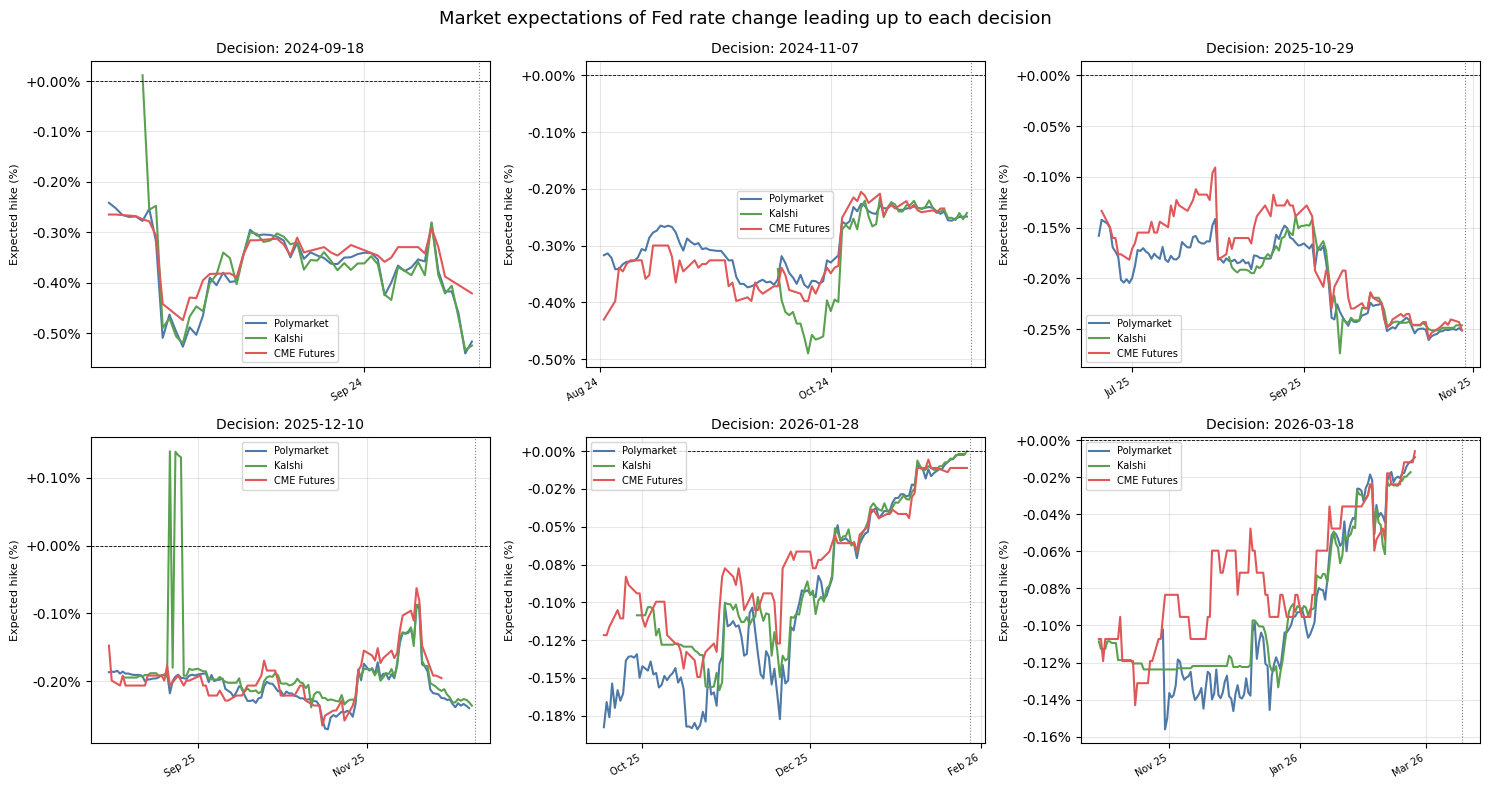

In [3]:

# Plot expectations leading up to decision for selected dates
import csv
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

DECISION_DATES = [
    '2024-09-18',
    '2024-11-07',
    '2025-10-29',
    '2025-12-10',
    '2026-01-28',
    '2026-03-18',
]

# Load data grouped by decision date
with open('expectations.csv') as f:
    all_rows = list(csv.DictReader(f))

def parse_row(r):
    return {
        'obs':     datetime.strptime(r['observed_day_pst'], '%Y-%m-%d'),
        'poly':    float(r['Polymarket_Exp'])  if r['Polymarket_Exp']  else None,
        'kalshi':  float(r['Kalshi_Exp'])      if r['Kalshi_Exp']      else None,
        'futures': float(r['Futures_Hike'])    if r['Futures_Hike']    else None,
    }

data = {dd: sorted([parse_row(r) for r in all_rows if r['decision_date'] == dd],
                   key=lambda x: x['obs'])
        for dd in DECISION_DATES}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, dd in zip(axes, DECISION_DATES):
    rows = data[dd]
    dec_date = datetime.strptime(dd, '%Y-%m-%d')

    for col, label, color in [('poly', 'Polymarket', '#4e79a7'),
                               ('kalshi', 'Kalshi', '#59a14f'),
                               ('futures', 'CME Futures', '#e15759')]:
        xs = [r['obs'] for r in rows if r[col] is not None]
        ys = [r[col]   for r in rows if r[col] is not None]
        if xs:
            ax.plot(xs, ys, label=label, color=color, linewidth=1.5)

    ax.axhline(0, color='black', linewidth=0.6, linestyle='--')
    ax.axvline(dec_date, color='grey', linewidth=0.8, linestyle=':')
    ax.set_title(f'Decision: {dd}', fontsize=10)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=7)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:+.2f}%'))
    ax.set_ylabel('Expected hike (%)', fontsize=8)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

fig.suptitle('Market expectations of Fed rate change leading up to each decision', fontsize=13)
plt.tight_layout()
plt.show()


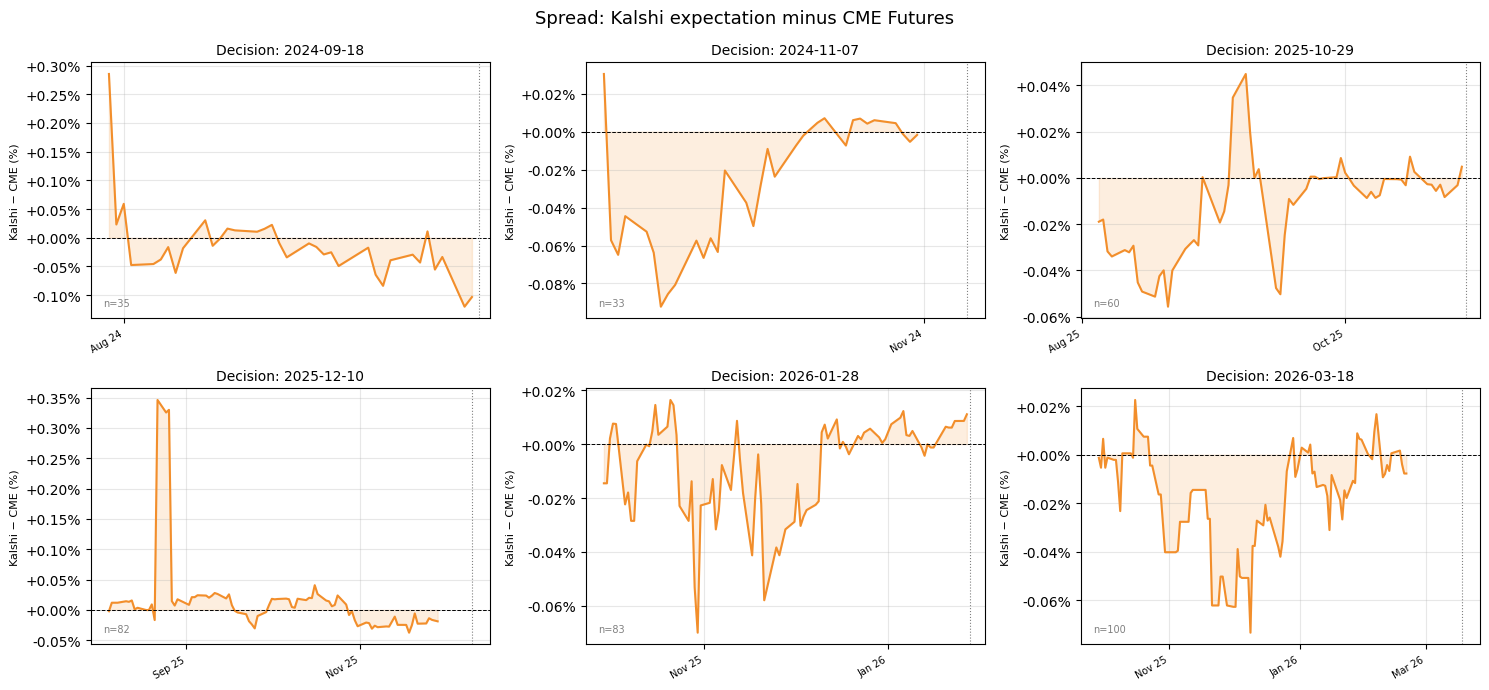

In [2]:

# Plot Kalshi minus CME Futures spread for the 6 selected decisions
import csv
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

DECISION_DATES = [
    '2024-09-18',
    '2024-11-07',
    '2025-10-29',
    '2025-12-10',
    '2026-01-28',
    '2026-03-18',
]

with open('expectations.csv') as f:
    all_rows = list(csv.DictReader(f))

def parse_row(r):
    return {
        'obs':     datetime.strptime(r['observed_day_pst'], '%Y-%m-%d'),
        'kalshi':  float(r['Kalshi_Exp'])   if r['Kalshi_Exp']   else None,
        'futures': float(r['Futures_Hike']) if r['Futures_Hike'] else None,
    }

data = {dd: sorted([parse_row(r) for r in all_rows if r['decision_date'] == dd],
                   key=lambda x: x['obs'])
        for dd in DECISION_DATES}

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
axes = axes.flatten()

for ax, dd in zip(axes, DECISION_DATES):
    rows = data[dd]
    dec_date = datetime.strptime(dd, '%Y-%m-%d')

    xs = [r['obs'] for r in rows if r['kalshi'] is not None and r['futures'] is not None]
    ys = [r['kalshi'] - r['futures'] for r in rows
          if r['kalshi'] is not None and r['futures'] is not None]

    if xs:
        ax.plot(xs, ys, color='#f28e2b', linewidth=1.5)
        ax.fill_between(xs, ys, 0, alpha=0.15, color='#f28e2b')

    ax.axhline(0, color='black', linewidth=0.7, linestyle='--')
    ax.axvline(dec_date, color='grey', linewidth=0.8, linestyle=':')
    ax.set_title(f'Decision: {dd}', fontsize=10)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=7)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:+.2f}%'))
    ax.set_ylabel('Kalshi − CME (%)', fontsize=8)
    ax.grid(True, alpha=0.3)
    if xs:
        ax.annotate(f'n={len(xs)}', xy=(0.03, 0.05), xycoords='axes fraction', fontsize=7, color='grey')

fig.suptitle('Spread: Kalshi expectation minus CME Futures', fontsize=13)
plt.tight_layout()
plt.show()


In [ ]:

# OU process fit: Kalshi - CME spread converging to zero
import csv
from datetime import datetime
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt

# --- Load spread series per decision ---
with open('expectations.csv') as f:
    all_rows = list(csv.DictReader(f))

decision_series = defaultdict(list)
for r in all_rows:
    if r['Kalshi_Exp'] and r['Futures_Hike']:
        decision_series[r['decision_date']].append({
            'obs': datetime.strptime(r['observed_day_pst'], '%Y-%m-%d'),
            'dec': datetime.strptime(r['decision_date'],    '%Y-%m-%d'),
            'spread': float(r['Kalshi_Exp']) - float(r['Futures_Hike']),
        })
for dd in decision_series:
    decision_series[dd].sort(key=lambda x: x['obs'])

# --- Build pooled regression arrays ---
# Model: dX/dt = -theta * X_{t-1} + eps  (OU reverting to 0)
def build_pairs(series):
    rows = []
    for i in range(1, len(series)):
        dt = (series[i]['obs'] - series[i-1]['obs']).days
        if dt <= 0:
            continue
        rows.append({
            'dX_dt':   (series[i]['spread'] - series[i-1]['spread']) / dt,
            'X_lag':   series[i-1]['spread'],
            'days_to': (series[i-1]['dec'] - series[i-1]['obs']).days,
        })
    return rows

all_pairs = []
for dd, series in decision_series.items():
    all_pairs.extend(build_pairs(series))

dX_dt = np.array([p['dX_dt'] for p in all_pairs])
X_lag = np.array([p['X_lag'] for p in all_pairs])

# --- OLS: dX/dt = -theta * X_lag  (no constant — reversion to zero) ---
theta_hat = -np.dot(X_lag, dX_dt) / np.dot(X_lag, X_lag)
residuals  = dX_dt + theta_hat * X_lag
n          = len(dX_dt)
se_ols     = np.sqrt(np.sum(residuals**2) / (n - 1) / np.dot(X_lag, X_lag))
half_life  = np.log(2) / theta_hat

# --- Bootstrap CI: resample whole decisions ---
rng = np.random.default_rng(42)
decision_keys = list(decision_series.keys())
boot_hl = []
for _ in range(5000):
    sampled = rng.choice(len(decision_keys), size=len(decision_keys), replace=True)
    pairs_b = sum([build_pairs(decision_series[decision_keys[i]]) for i in sampled], [])
    dX_b = np.array([p['dX_dt'] for p in pairs_b])
    Xl_b = np.array([p['X_lag'] for p in pairs_b])
    th_b = -np.dot(Xl_b, dX_b) / np.dot(Xl_b, Xl_b)
    if th_b > 0:
        boot_hl.append(np.log(2) / th_b)
ci_lo, ci_hi = np.percentile(boot_hl, [2.5, 97.5])

print(f"OU fit ({len(decision_keys)} decisions, n={n} pairs)")
print(f"  theta     = {theta_hat:.4f}/day  (SE={se_ols:.4f}, t={theta_hat/se_ols:.2f})")
print(f"  Half-life = {half_life:.1f} days  [95% CI: {ci_lo:.1f}–{ci_hi:.1f} days]")

# --- Plots ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Phase plot
ax = axes[0]
colors = plt.cm.tab10(np.linspace(0, 1, len(decision_keys)))
for i, dd in enumerate(sorted(decision_keys)):
    pairs = build_pairs(decision_series[dd])
    ax.scatter([p['X_lag'] for p in pairs], [p['dX_dt'] for p in pairs],
               s=8, alpha=0.5, color=colors[i], label=dd)
xl_range = np.linspace(X_lag.min(), X_lag.max(), 100)
ax.plot(xl_range, -theta_hat * xl_range, 'k-', linewidth=2, label=f'OU fit (θ={theta_hat:.3f}/d)')
ax.axhline(0, color='grey', linewidth=0.5)
ax.axvline(0, color='grey', linewidth=0.5)
ax.set_xlabel('Spread X(t−1) (%)')
ax.set_ylabel('dX/dt (%/day)')
ax.set_title('Phase plot')
ax.legend(fontsize=5, ncol=2)

# 2. Empirical convergence: mean |spread| by days-to-decision bin
ax = axes[1]
days_to = np.array([p['days_to'] for p in all_pairs])
abs_X   = np.abs(X_lag)
bins = np.arange(0, days_to.max() + 10, 10)
bin_mids, bin_means = [], []
for lo, hi in zip(bins[:-1], bins[1:]):
    mask = (days_to >= lo) & (days_to < hi)
    if mask.sum() >= 3:
        bin_mids.append((lo + hi) / 2)
        bin_means.append(abs_X[mask].mean())
ax.bar(bin_mids, bin_means, width=9, color='#4e79a7', alpha=0.7)
# OU envelope: anchored at furthest bin, decays as days_to -> 0
d_range = np.linspace(0, max(bin_mids), 200)
envelope = bin_means[-1] * np.exp(-theta_hat * (max(bin_mids) - d_range))
ax.plot(d_range, envelope, 'r--', linewidth=1.5, label='OU envelope')
ax.set_xlabel('Days to decision')
ax.set_ylabel('Mean |spread| (%)')
ax.set_title('Empirical convergence')
ax.legend(fontsize=8)

# 3. Bootstrap half-life distribution
ax = axes[2]
ax.hist(boot_hl, bins=60, color='#59a14f', alpha=0.8, edgecolor='none')
ax.axvline(half_life, color='black', linewidth=1.5, label=f'Estimate: {half_life:.1f}d')
ax.axvline(ci_lo,     color='red',   linewidth=1,   linestyle='--',
           label=f'95% CI: [{ci_lo:.1f}, {ci_hi:.1f}]d')
ax.axvline(ci_hi,     color='red',   linewidth=1,   linestyle='--')
ax.set_xlabel('Half-life (days)')
ax.set_ylabel('Bootstrap count')
ax.set_title('Bootstrap distribution of half-life')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


In [ ]:

# Brownian Bridge model for the Kalshi - CME spread
#
# Model: dX_t = -(X_t / tau_t) dt + sigma dW_t   where tau_t = T - t (days to decision)
#
# This is the SDE for a Brownian Bridge pinned to X(T) = 0.
# Conditional mean:  E[X(tau) | X(tau_0)] = X(tau_0) * tau / tau_0
# Conditional var:   Var[X(tau) | X(tau_0)] = sigma^2 * tau * (tau_0 - tau) / tau_0
#
# Transformation: Y(t) = X(t) / tau_t is a martingale with dY = sigma/tau_t * dW_t
# So increments dY_i = X_{i+1}/tau_{i+1} - X_i/tau_i are i.i.d. with
#   Var[dY_i] = sigma^2 * delta_i / (tau_i * tau_{i+1})
# MLE: sigma^2 = (1/n) * sum( dY_i^2 * tau_i * tau_{i+1} / delta_i )

import csv
from datetime import datetime
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

with open('expectations.csv') as f:
    all_rows = list(csv.DictReader(f))

decision_series = defaultdict(list)
for r in all_rows:
    if r['Kalshi_Exp'] and r['Futures_Hike']:
        decision_series[r['decision_date']].append({
            'obs': datetime.strptime(r['observed_day_pst'], '%Y-%m-%d'),
            'dec': datetime.strptime(r['decision_date'],    '%Y-%m-%d'),
            'spread': float(r['Kalshi_Exp']) - float(r['Futures_Hike']),
        })
for dd in decision_series:
    decision_series[dd].sort(key=lambda x: x['obs'])

def build_bb_pairs(series):
    pairs = []
    for i in range(1, len(series)):
        tau0  = (series[i-1]['dec'] - series[i-1]['obs']).days
        tau1  = (series[i]['dec']   - series[i]['obs']).days
        delta = (series[i]['obs']   - series[i-1]['obs']).days
        if delta <= 0 or tau0 <= 0 or tau1 <= 0:
            continue
        X0, X1 = series[i-1]['spread'], series[i]['spread']
        pairs.append({'dY': X1/tau1 - X0/tau0, 'tau0': tau0, 'tau1': tau1,
                      'delta': delta, 'X0': X0, 'X1': X1,
                      'dec': series[i-1]['dec'].strftime('%Y-%m-%d')})
    return pairs

all_pairs = sum([build_bb_pairs(s) for s in decision_series.values()], [])

dY_arr  = np.array([p['dY']  for p in all_pairs])
var_arr = np.array([p['tau0'] * p['tau1'] / p['delta'] for p in all_pairs])   # = 1/Var per sigma^2

sigma2_hat = np.mean(dY_arr**2 * var_arr)
sigma_hat  = np.sqrt(sigma2_hat)

# Bootstrap CI over decisions
rng = np.random.default_rng(42)
decision_keys = list(decision_series.keys())
boot_sigma = []
for _ in range(5000):
    sampled = rng.choice(len(decision_keys), size=len(decision_keys), replace=True)
    pairs_b = sum([build_bb_pairs(decision_series[decision_keys[i]]) for i in sampled], [])
    dY_b  = np.array([p['dY']  for p in pairs_b])
    var_b = np.array([p['tau0'] * p['tau1'] / p['delta'] for p in pairs_b])
    boot_sigma.append(np.sqrt(np.mean(dY_b**2 * var_b)))
ci_lo, ci_hi = np.percentile(boot_sigma, [2.5, 97.5])

# Standardised residuals: dY / sqrt(sigma^2 * delta / (tau0 * tau1)) ~ N(0,1)
std_resid = dY_arr / np.sqrt(sigma2_hat / var_arr)

print(f"Brownian Bridge fit ({len(decision_keys)} decisions, n={len(all_pairs)} pairs)")
print(f"  sigma = {sigma_hat:.6f} %/sqrt(day)  [95% CI: {ci_lo:.6f}–{ci_hi:.6f}]")
print(f"  Interpretation: at tau days to decision, 1-sigma spread uncertainty = {sigma_hat:.4f} * sqrt(tau) %")
print(f"  e.g. 30d out: ±{sigma_hat*np.sqrt(30):.4f}%   7d out: ±{sigma_hat*np.sqrt(7):.4f}%   1d out: ±{sigma_hat:.4f}%")
print(f"\n  Std resid: mean={std_resid.mean():.3f}, std={std_resid.std():.3f}, skew={stats.skew(std_resid):.3f}, kurtosis={stats.kurtosis(std_resid):.3f}")

# --- Plots ---
fig = plt.figure(figsize=(16, 10))
gs  = fig.add_gridspec(2, 3, hspace=0.4, wspace=0.35)

# 1. Standardised residuals histogram + N(0,1)
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(std_resid, bins=40, density=True, color='#4e79a7', alpha=0.7, edgecolor='none')
x_range = np.linspace(-5, 5, 200)
ax1.plot(x_range, stats.norm.pdf(x_range), 'r-', linewidth=1.5, label='N(0,1)')
ax1.set_xlim(-6, 6)
ax1.set_xlabel('Standardised residual')
ax1.set_ylabel('Density')
ax1.set_title('Residuals vs N(0,1)')
ax1.legend(fontsize=8)

# 2. Q-Q plot
ax2 = fig.add_subplot(gs[0, 1])
(osm, osr), (slope, intercept, r) = stats.probplot(std_resid, dist='norm')
ax2.scatter(osm, osr, s=6, alpha=0.5, color='#4e79a7')
ax2.plot(osm, slope*np.array(osm)+intercept, 'r-', linewidth=1.5)
ax2.set_xlabel('Theoretical quantiles')
ax2.set_ylabel('Sample quantiles')
ax2.set_title(f'Q-Q plot  (r={r:.3f})')

# 3. Bootstrap sigma distribution
ax3 = fig.add_subplot(gs[0, 2])
ax3.hist(boot_sigma, bins=50, color='#59a14f', alpha=0.8, edgecolor='none')
ax3.axvline(sigma_hat, color='black', linewidth=1.5, label=f'σ = {sigma_hat:.5f}')
ax3.axvline(ci_lo, color='red', linewidth=1, linestyle='--', label=f'95% CI: [{ci_lo:.5f}, {ci_hi:.5f}]')
ax3.axvline(ci_hi, color='red', linewidth=1, linestyle='--')
ax3.set_xlabel('sigma (%/sqrt(day))')
ax3.set_ylabel('Bootstrap count')
ax3.set_title('Bootstrap distribution of σ')
ax3.legend(fontsize=7)

# 4. Normalised actual paths vs BB expected (tau/tau_0)
ax4 = fig.add_subplot(gs[1, :2])
colors = plt.cm.tab10(np.linspace(0, 1, len(decision_keys)))
for i, dd in enumerate(sorted(decision_keys)):
    series = decision_series[dd]
    X0_ref = series[0]['spread']
    if abs(X0_ref) < 1e-6:
        continue
    taus = [(r['dec'] - r['obs']).days for r in series]
    tau0 = taus[0]
    norm_spreads = [r['spread'] / X0_ref for r in series]
    norm_taus    = [tau / tau0 for tau in taus]
    ax4.plot(norm_taus, norm_spreads, color=colors[i], alpha=0.7, linewidth=1.2, label=dd)
tau_line = np.linspace(0, 1, 100)
ax4.plot(tau_line, tau_line, 'k--', linewidth=2, label='BB expected: τ/τ₀')
ax4.axhline(0, color='grey', linewidth=0.5)
ax4.set_xlabel('Fraction of time remaining (τ/τ₀)')
ax4.set_ylabel('Normalised spread (X/X₀)')
ax4.set_title('Actual normalised paths vs BB expected')
ax4.legend(fontsize=6, ncol=2)
ax4.invert_xaxis()   # left = far from decision, right = decision day

# 5. Trading implication: E[profit] and ±1 sigma band vs close time
ax5 = fig.add_subplot(gs[1, 2])
tau0_ex = 60   # example: enter 60 days before decision
X0_ex   = 0.05 # example spread at entry (%)
tau_close = np.linspace(1, tau0_ex, 200)
frac_captured = 1 - tau_close / tau0_ex
std_residual  = sigma_hat * np.sqrt(tau_close * (tau0_ex - tau_close) / tau0_ex)
ax5.plot(tau_close, frac_captured * X0_ex * 100, 'k-', linewidth=1.5, label='E[profit]')
ax5.fill_between(tau_close,
                 (frac_captured * X0_ex - std_residual) * 100,
                 (frac_captured * X0_ex + std_residual) * 100,
                 alpha=0.2, color='#f28e2b', label='±1σ')
ax5.axhline(0, color='grey', linewidth=0.5, linestyle='--')
ax5.set_xlabel('Days remaining at close (τ_close)')
ax5.set_ylabel('Profit (bp)')
ax5.set_title(f'Close-early trade-off\n(entry: τ₀={tau0_ex}d, X₀={X0_ex*100:.0f}bp)')
ax5.legend(fontsize=8)
ax5.invert_xaxis()

fig.suptitle('Brownian Bridge model: X(t) pinned to 0 at decision date', fontsize=13)
plt.show()


In [ ]:
# Spread Analysis: Test if mean reverting (OU Process)

In [ ]:
# Spread Analysis: Test if Dampened OU Process